In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

In [ ]:
hotel_data_path = '../data/raw/hotel_booking.csv'

In [5]:
hotel_df = pd.read_csv(hotel_data_path)

In [6]:
hotel_df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [11]:
hotel_df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [131]:
hotel_df.shape

(119390, 36)

In [11]:
hotel_df["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [26]:
# % of cancelations
hotel_df["is_canceled"].value_counts()[1]/hotel_df.shape[0]

0.37041628277075134

In [30]:
print("mean lead time:",hotel_df["lead_time"].mean())
print("median lead time:",hotel_df["lead_time"].median())
print("standard deviation of lead time:",hotel_df["lead_time"].std())

mean lead time: 104.01141636652986
median lead time: 69.0
standard deviation of lead time: 106.86309704798579


outliers: last minute resesrvations

Text(0.5, 0, 'lead time in days')

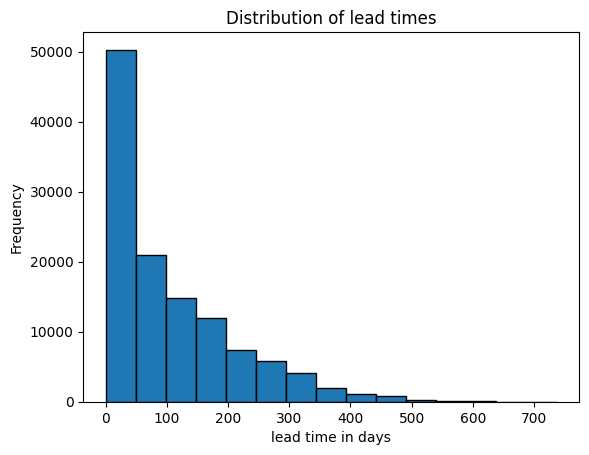

In [163]:
hotel_df["lead_time"].plot(kind="hist",bins=15,edgecolor="black")
plt.title("Distribution of lead times")
plt.xlabel("lead time in days")

Text(0.5, 0, 'lead time in days')

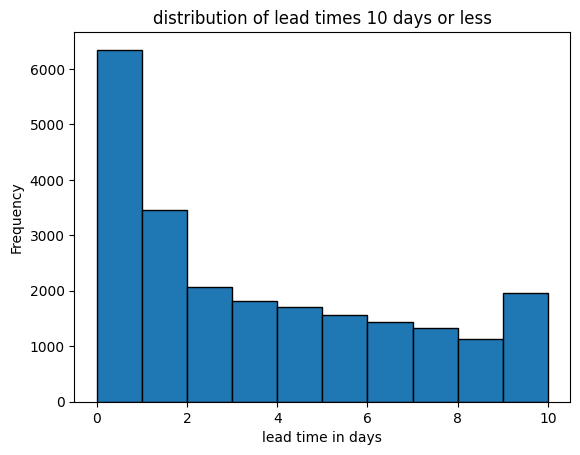

In [161]:
hotel_df[hotel_df["lead_time"]<11]["lead_time"].plot(kind="hist",bins=10,edgecolor="black")
plt.title("distribution of lead times 10 days or less")
plt.xlabel("lead time in days")

Text(0.5, 0, 'lead time in days')

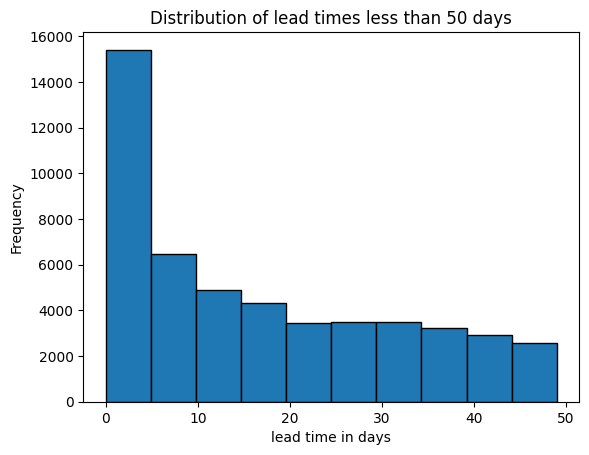

In [162]:
hotel_df[hotel_df["lead_time"]<50]["lead_time"].plot(kind="hist",bins=10,edgecolor="black")
plt.title("Distribution of lead times less than 50 days")
plt.xlabel("lead time in days")

In [55]:
# 14% of reservations are made with less than 6 days lead time
hotel_df[hotel_df["lead_time"]<6]["lead_time"].count()/hotel_df.shape[0]

0.14213920763883073

In [57]:
# 6% of reservations are made with more than 300 days lead time
hotel_df[hotel_df["lead_time"]>300]["lead_time"].count()/hotel_df.shape[0]

0.06606080911299103

Text(0, 0.5, 'Lead time # of days')

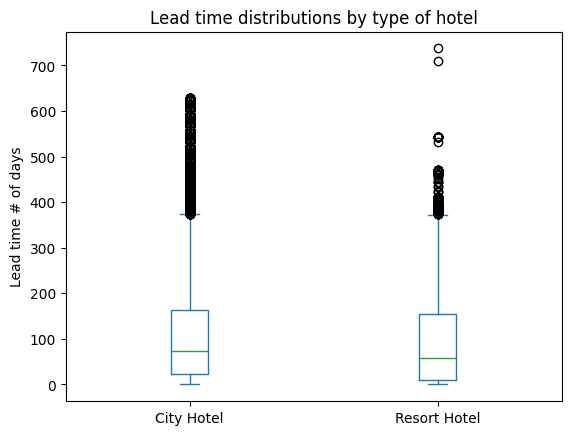

In [152]:
# lead time by hotel
hotel_df.plot(kind="box",column="lead_time",by="hotel")
plt.title("Lead time distributions by type of hotel")
plt.ylabel("Lead time # of days")

Text(0.5, 0, 'reservation outcome (1= canceled)')

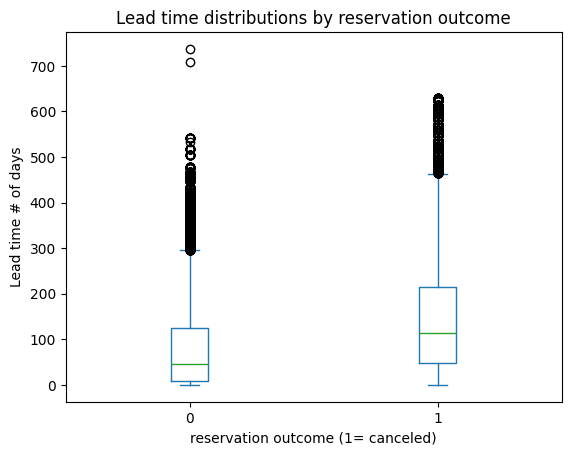

In [6]:
hotel_df.plot(kind="box",column="lead_time",by="is_canceled")
plt.title("Lead time distributions by reservation outcome")
plt.ylabel("Lead time # of days")
plt.xlabel("reservation outcome (1= canceled)")

In [132]:
city_data = hotel_df[hotel_df["hotel"]=="City Hotel"]["lead_time"]
print(city_data.quantile([0.25,0.5,0.75]))

0.25     23.0
0.50     74.0
0.75    163.0
Name: lead_time, dtype: float64


In [134]:
resort_data = hotel_df[hotel_df["hotel"]=="Resort Hotel"]["lead_time"]
print(resort_data.quantile([0.25,0.5,0.75]))

0.25     10.0
0.50     57.0
0.75    155.0
Name: lead_time, dtype: float64


In [71]:
correlation = hotel_df["is_canceled"].corr(hotel_df["lead_time"])
correlation

0.29312335576071896

In [80]:
greater_5 = hotel_df[hotel_df["lead_time"]>5].copy()

In [81]:
greater_5["lead_time"].corr(greater_5["is_canceled"])

0.23069656875447261

Excluding shorter lead times does not improve the correlation between cancellations lead time.

Text(0.5, 0, 'lead time in days')

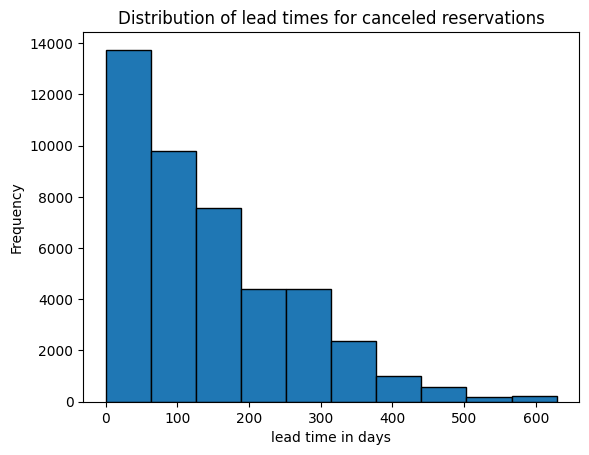

In [164]:
hotel_df.loc[hotel_df["is_canceled"]==1,"lead_time"].plot(kind="hist",edgecolor="black")
plt.title("Distribution of lead times for canceled reservations")
plt.xlabel("lead time in days")

In [86]:
hotel_df["arrival_date_year"].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [87]:
hotel_df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [89]:
hotel_df["arrival_date_month"].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

In [27]:
def counts(df,attribute):
    print(df[attribute].value_counts())

In [99]:
counts(hotel_df,"market_segment")

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


In [97]:
counts(hotel_df,"meal")

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


In [100]:
counts(hotel_df,"distribution_channel")

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


In [101]:
counts(hotel_df,"is_repeated_guest")

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64


In [102]:
counts(hotel_df,"previous_cancellations")

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
19        19
5         19
14        14
13        12
21         1
Name: count, dtype: int64


In [110]:
counts(hotel_df,"reservation_status")

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


In [115]:
hotel_df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [119]:
hotel_df[["is_canceled","reservation_status"]].value_counts()

is_canceled  reservation_status
0            Check-Out             75166
1            Canceled              43017
             No-Show                1207
Name: count, dtype: int64

In [28]:
def correlation(df,attribute1,attribute2):
    print(df[attribute1].corr(df[attribute2]))

In [126]:
correlation(hotel_df,"is_canceled","previous_cancellations")

0.11013280822284725


In [130]:
correlation(hotel_df,"is_canceled","booking_changes")

-0.1443809910613272


In [166]:
stats.pointbiserialr(hotel_df["is_canceled"],hotel_df["lead_time"])

SignificanceResult(statistic=0.2931233557606123, pvalue=0.0)

In [170]:
correlation(hotel_df,"is_canceled","arrival_date_week_number")

0.008148065395052646


In [172]:
correlation(hotel_df,"is_canceled","adults")

0.06001721283956598


In [173]:
correlation(hotel_df,"is_canceled","children")

0.005047790029268779


In [15]:
hotel_df["distribution_channel"] = hotel_df["distribution_channel"].astype("category")

In [16]:
hotel_df["dist_channel_code"] = hotel_df["distribution_channel"].cat.codes

In [17]:
hotel_df[["dist_channel_code","distribution_channel"]].value_counts()

dist_channel_code  distribution_channel
3                  TA/TO                   97870
1                  Direct                  14645
0                  Corporate                6677
2                  GDS                       193
4                  Undefined                   5
Name: count, dtype: int64

In [191]:
# Create a contingency table
contingency_table = pd.crosstab(hotel_df['is_canceled'], hotel_df['dist_channel_code'])

# Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-Squared statistic: 3745.794123751679
P-value: 0.0
Degrees of freedom: 4
Expected frequencies: [[4.20373048e+03 9.22025354e+03 1.21509657e+02 6.16173584e+04
  3.14791859e+00]
 [2.47326952e+03 5.42474646e+03 7.14903426e+01 3.62526416e+04
  1.85208141e+00]]


In [ ]:
# performing fishers exact test on the data 
odd_ratio, p_value = stats.fisher_exact(data) 
print('odd ratio is : ' + str(odd_ratio)) 
print('p_value is : ' + str(p_value)) 

In [192]:
# Create a contingency table
contingency_table = pd.crosstab(hotel_df['is_canceled'], hotel_df['adults'])

# Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-Squared statistic: 902.5933136266607
P-value: 1.4124977753730983e-184
Degrees of freedom: 13
Expected frequencies: [[2.53722238e+02 1.44974243e+04 5.64610678e+04 3.90467821e+03
  3.90341905e+01 1.25916743e+00 6.29583717e-01 6.29583717e-01
  1.25916743e+00 3.14791859e+00 1.25916743e+00 6.29583717e-01
  6.29583717e-01 6.29583717e-01]
 [1.49277762e+02 8.52957574e+03 3.32189322e+04 2.29732179e+03
  2.29658095e+01 7.40832566e-01 3.70416283e-01 3.70416283e-01
  7.40832566e-01 1.85208141e+00 7.40832566e-01 3.70416283e-01
  3.70416283e-01 3.70416283e-01]]


In [23]:
# Create a contingency table
contingency_table = pd.crosstab(hotel_df['is_canceled'], hotel_df['hotel'])

# Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-Squared statistic: 2224.924903923313
P-value: 0.0
Degrees of freedom: 1
Expected frequencies: [[49944.8762878 25221.1237122]
 [29385.1237122 14838.8762878]]


In [24]:
p

0.0

In [12]:
hotel_df[['arrival_date_year','arrival_date_month','is_canceled']].groupby(["arrival_date_year",'arrival_date_month']).count()

is_canceled
arrival_date_year arrival_date_month             
2015              August                     3889
                  December                   2920
                  July                       2776
                  November                   2340
                  October                    4957
                  September                  5114
2016              April                      5428
                  August                     5063
                  December                   3860
                  February                   3891
                  January                    2248
                  July                       4572
                  June                       5292
                  March                      4824
                  May                        5478
                  November                   4454
                  October                    6203
                  September                  5394
2017              April                      5661
                  August                     4925
                  February                   4177
                  January                    3681
                  July                       5313
                  June                       5647
                  March                      4970
                  May                        6313

In [31]:
counts(hotel_df,'total_of_special_requests')

total_of_special_requests
0    70318
1    33226
2    12969
3     2497
4      340
5       40
Name: count, dtype: int64


In [29]:
correlation(hotel_df,'is_canceled','total_of_special_requests')

-0.2346577739690241


In [30]:
# Create a contingency table
contingency_table = pd.crosstab(hotel_df['is_canceled'], hotel_df['total_of_special_requests'])

# Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-Squared statistic: 8406.499740187332
P-value: 0.0
Degrees of freedom: 5
Expected frequencies: [[4.42710678e+04 2.09185486e+04 8.16507123e+03 1.57207054e+03
  2.14058464e+02 2.51833487e+01]
 [2.60469322e+04 1.23074514e+04 4.80392877e+03 9.24929458e+02
  1.25941536e+02 1.48166513e+01]]
